In [1]:
from pathlib import Path
import json
import re
import pandas as pd
import numpy as np
from IPython.display import display

BASE = Path.cwd()

DOWNLOAD_DIRS = {
    "image_only": BASE / "wandb_downloads_image_only",
    "student_simulation": BASE / "wandb_downloads_student_simulation",
    "text_image_chart_only_action_text": BASE / "wandb_downloads_text_image_chart_only_action_text",
    "text_image_chart_only2": BASE / "wandb_downloads_text_image_chart_only2",
    "text_only": BASE / "wandb_downloads_text_only",
}

for name, path in DOWNLOAD_DIRS.items():
    print(f"{name:40s}", path, "EXISTS =", path.exists())

rows = []

target_files = [
    "summary.json",
    "trajectory.json",
    "interaction_log.json",
    "steps.json",
    "output.log",
]

for root_name, root_path in DOWNLOAD_DIRS.items():
    if not root_path.exists():
        continue

    for file_name in target_files:
        files = list(root_path.rglob(file_name))
        rows.append({
            "root": root_name,
            "file": file_name,
            "count": len(files),
        })

file_dist_df = pd.DataFrame(rows)

display(
    file_dist_df
    .pivot(index="root", columns="file", values="count")
    .fillna(0)
    .astype(int)
)

image_only                               \\wsl.localhost\Ubuntu\home\lly\projects\project\wandb_downloads_image_only EXISTS = True
student_simulation                       \\wsl.localhost\Ubuntu\home\lly\projects\project\wandb_downloads_student_simulation EXISTS = True
text_image_chart_only_action_text        \\wsl.localhost\Ubuntu\home\lly\projects\project\wandb_downloads_text_image_chart_only_action_text EXISTS = True
text_image_chart_only2                   \\wsl.localhost\Ubuntu\home\lly\projects\project\wandb_downloads_text_image_chart_only2 EXISTS = True
text_only                                \\wsl.localhost\Ubuntu\home\lly\projects\project\wandb_downloads_text_only EXISTS = True


file,interaction_log.json,output.log,steps.json,summary.json,trajectory.json
root,,,,,
image_only,360,36,360,360,360
student_simulation,40,4,40,40,40
text_image_chart_only2,360,36,360,360,360
text_image_chart_only_action_text,360,36,360,360,360
text_only,1259,126,1259,1259,1259


In [2]:
def safe_load_json(path):
    try:
        with open(path, "r", encoding="utf-8") as f:
            return json.load(f)
    except Exception as e:
        print("Failed to load:", path, e)
        return None


def find_nearest_file(start_dir, filename, max_up=5):
    """
    从 summary.json 所在目录开始，向上找 output.log。
    适合 run_00/summary.json 这种结构。
    """
    start_dir = Path(start_dir)
    candidates = [start_dir] + list(start_dir.parents[:max_up])
    for d in candidates:
        p = d / filename
        if p.exists():
            return p
    return None


def read_text_if_exists(path):
    if path is None or not Path(path).exists():
        return ""
    try:
        return Path(path).read_text(encoding="utf-8", errors="replace")
    except Exception:
        return ""


def parse_output_log(log_text):
    """
    从 output.log 里解析 config/env/model/run_name。
    """
    out = {}

    patterns = {
        "config": r"Config:\s*(.+)",
        "env_config": r"Env override:\s*(.+)",
        "model_config": r"Model override:\s*(.+)",
        "run_name": r"Run name:\s*(.+)",
        "output_dir": r"Output dir:\s*(.+)",
        "task_mode": r"Task mode:\s*(.+)",
        "observation_mode": r"Observation mode:\s*(.+)",
        "target_variable": r"Target variable:\s*(.+)",
        "naming_mode": r"Naming mode:\s*(.+)",
        "action_mode": r"Action mode:\s*(.+)",
        "n_runs": r"N runs:\s*(\d+)",
    }

    for key, pat in patterns.items():
        m = re.search(pat, log_text)
        out[key] = m.group(1).strip() if m else None

    return out


FORMULAS = [
    "beers_wavelength",
    "beers",
    "concentration",
    "ohm",
    "resistors",
    "kinematics",
    "mass",
    "distance",
]

SETUPS = ["concrete", "abbrev", "abstract"]

KNOWN_MODELS = [
    "model_qwen25_vl_3b",
    "model_qwen25_vl_7b",
    "model_qwen25_3b",
    "model_qwen25_7b",
    "model_qwen35_4b",
    "model_qwen35_9b",
    "model_llama31_8b",
    "model_mistral_7b",
    "model_gemma3_4b",
]


def infer_formula(text):
    text = str(text).lower()
    for f in FORMULAS:
        if f in text:
            return f
    return None


def infer_setup(text):
    text = str(text).lower()
    for s in SETUPS:
        if re.search(rf"(^|[_\-/]){s}($|[_\-/\.])", text):
            return s
    return None


def infer_model(text):
    text = str(text)
    for m in KNOWN_MODELS:
        if m in text:
            return m

    # fallback: qwen25_vl_3b -> model_qwen25_vl_3b
    for m in KNOWN_MODELS:
        short = m.replace("model_", "")
        if short in text:
            return m

    # fallback regex
    m = re.search(r"(model_[A-Za-z0-9]+(?:_[A-Za-z0-9]+)*)", text)
    return m.group(1) if m else None


def infer_run_idx(text):
    text = str(text)
    patterns = [
        r"run[_\-](\d+)",
        r"run_(\d+)",
        r"-(\d+)(?:$|[:/])",
    ]
    for pat in patterns:
        m = re.search(pat, text)
        if m:
            return int(m.group(1))
    return None


def infer_modality(root_name, combined_text, config=None, run_name=None):
    """
    这里故意保留 modality_detail，避免把 chart-only 的不同版本误混在一起。
    """
    s = " ".join([
        str(root_name),
        str(combined_text),
        str(config),
        str(run_name),
    ]).lower()

    modality = None
    detail = None

    if "simulation" in s:
        modality = "Simulation-only"
        detail = "simulation"
    elif "text_only" in s or "config_text_only" in s:
        modality = "Text-only"
        detail = "text_only"
    elif "chart_only_no_action" in s or "image_only" in s:
        modality = "Chart-only"
        detail = "chart_only_no_action"
    elif "chart_only" in s:
        modality = "Chart-only"
        detail = "chart_only_action_text_or_unknown"
    elif "text_image" in s:
        modality = "Text+image"
        detail = "text_image"
    else:
        modality = "Unknown"
        detail = "unknown"

    return modality, detail


episode_rows = []

for root_name, root_path in DOWNLOAD_DIRS.items():
    if not root_path.exists():
        continue

    summary_paths = list(root_path.rglob("summary.json"))
    print(root_name, "summary files:", len(summary_paths))

    for summary_path in summary_paths:
        summary = safe_load_json(summary_path)
        if not isinstance(summary, dict):
            continue

        episode_dir = summary_path.parent
        output_log_path = find_nearest_file(episode_dir, "output.log")
        log_text = read_text_if_exists(output_log_path)
        log_info = parse_output_log(log_text)

        path_text = str(summary_path)
        combined_text = " ".join([
            root_name,
            path_text,
            log_text,
            str(log_info),
        ])

        evaluation = summary.get("evaluation", {}) or {}

        row = {
            "root": root_name,
            "episode_dir": str(episode_dir),
            "summary_path": str(summary_path),
            "trajectory_path": str(episode_dir / "trajectory.json"),
            "interaction_log_path": str(episode_dir / "interaction_log.json"),
            "steps_path": str(episode_dir / "steps.json"),
            "output_log_path": str(output_log_path) if output_log_path else None,
        }

        # top-level summary fields
        for k, v in summary.items():
            if k not in ["evaluation", "image_paths"]:
                row[k] = v

        # evaluation fields
        for k, v in evaluation.items():
            row[k] = v

        # log fields
        row.update(log_info)

        # inferred metadata
        row["formula"] = infer_formula(log_info.get("env_config") or combined_text)
        row["setup"] = infer_setup(log_info.get("env_config") or combined_text)
        row["model"] = infer_model(log_info.get("model_config") or combined_text)
        row["run_idx"] = infer_run_idx(combined_text)

        modality, modality_detail = infer_modality(
            root_name=root_name,
            combined_text=combined_text,
            config=log_info.get("config"),
            run_name=log_info.get("run_name"),
        )
        row["modality"] = modality
        row["modality_detail"] = modality_detail

        # useful derived indicators
        row["success_int"] = int(bool(row.get("success", False)))
        row["equation_correct_int"] = int(bool(row.get("equation_correct", False)))
        row["finish_called_int"] = int(bool(row.get("finish_called", False)))
        row["forced_finish_int"] = int(bool(row.get("forced_finish", False)))

        term = row.get("termination_reason")
        row["finish_wrong_int"] = int(term == "finish_wrong")
        row["parse_error_int"] = int((term == "parse_error") or (row.get("parse_error") not in [None, "", False]))

        episode_rows.append(row)


df = pd.DataFrame(episode_rows)

print("Total episodes:", len(df))
display(df.head())
display(df.columns.to_frame(index=False).rename(columns={0: "columns"}))

image_only summary files: 360
student_simulation summary files: 40
text_image_chart_only_action_text summary files: 360
text_image_chart_only2 summary files: 360
text_only summary files: 1259
Total episodes: 2379


,root,episode_dir,summary_path,trajectory_path,interaction_log_path,steps_path,output_log_path,final_equation,finish_reason,finish_reached,...,model,run_idx,modality,modality_detail,success_int,equation_correct_int,finish_called_int,forced_finish_int,finish_wrong_int,parse_error_int
0,image_only,\\wsl.localhost\Ubuntu\home\lly\projects\proje...,\\wsl.localhost\Ubuntu\home\lly\projects\proje...,\\wsl.localhost\Ubuntu\home\lly\projects\proje...,\\wsl.localhost\Ubuntu\home\lly\projects\proje...,\\wsl.localhost\Ubuntu\home\lly\projects\proje...,None,d = d1 + d2 + d3,NaN,True,...,model_qwen25_vl_7b,None,Chart-only,chart_only_no_action,1,1,1,0,0,0
1,image_only,\\wsl.localhost\Ubuntu\home\lly\projects\proje...,\\wsl.localhost\Ubuntu\home\lly\projects\proje...,\\wsl.localhost\Ubuntu\home\lly\projects\proje...,\\wsl.localhost\Ubuntu\home\lly\projects\proje...,\\wsl.localhost\Ubuntu\home\lly\projects\proje...,None,x = v + x0,NaN,True,...,model_qwen25_vl_7b,None,Chart-only,chart_only_no_action,0,0,1,0,1,0
2,image_only,\\wsl.localhost\Ubuntu\home\lly\projects\proje...,\\wsl.localhost\Ubuntu\home\lly\projects\proje...,\\wsl.localhost\Ubuntu\home\lly\projects\proje...,\\wsl.localhost\Ubuntu\home\lly\projects\proje...,\\wsl.localhost\Ubuntu\home\lly\projects\proje...,None,m = rho + V,NaN,True,...,model_qwen25_vl_3b,None,Chart-only,chart_only_no_action,0,0,1,0,1,0
3,image_only,\\wsl.localhost\Ubuntu\home\lly\projects\proje...,\\wsl.localhost\Ubuntu\home\lly\projects\proje...,\\wsl.localhost\Ubuntu\home\lly\projects\proje...,\\wsl.localhost\Ubuntu\home\lly\projects\proje...,\\wsl.localhost\Ubuntu\home\lly\projects\proje...,None,Rt = R2,NaN,True,...,model_qwen25_vl_3b,None,Chart-only,chart_only_no_action,0,0,1,0,1,0
4,image_only,\\wsl.localhost\Ubuntu\home\lly\projects\proje...,\\wsl.localhost\Ubuntu\home\lly\projects\proje...,\\wsl.localhost\Ubuntu\home\lly\projects\proje...,\\wsl.localhost\Ubuntu\home\lly\projects\proje...,\\wsl.localhost\Ubuntu\home\lly\projects\proje...,None,m = e^(rho * V),NaN,True,...,model_qwen25_vl_3b,None,Chart-only,chart_only_no_action,0,0,1,0,1,0


,columns
0,root
1,episode_dir
2,summary_path
3,trajectory_path
4,interaction_log_path
5,steps_path
6,output_log_path
7,final_equation
8,finish_reason
9,finish_reached


In [3]:
# 1. 每个 modality 多少条
display(
    df.groupby(["root", "modality", "modality_detail"])
      .size()
      .reset_index(name="n")
      .sort_values(["root", "modality", "modality_detail"])
)

# 2. 每个 formula × setup × modality 多少条
display(
    df.groupby(["modality", "modality_detail", "formula", "setup"])
      .size()
      .reset_index(name="n")
      .sort_values(["modality", "formula", "setup"])
)

# 3. 每个 model × modality 多少条
display(
    df.groupby(["modality", "modality_detail", "model"])
      .size()
      .reset_index(name="n")
      .sort_values(["modality", "model"])
)

# 4. termination reason 分布
display(
    df.groupby(["modality", "modality_detail", "termination_reason"])
      .size()
      .reset_index(name="n")
      .sort_values(["modality", "modality_detail", "n"], ascending=[True, True, False])
)

,root,modality,modality_detail,n
0,image_only,Chart-only,chart_only_no_action,360
1,student_simulation,Simulation-only,simulation,40
2,text_image_chart_only2,Chart-only,chart_only_no_action,360
3,text_image_chart_only_action_text,Chart-only,chart_only_action_text_or_unknown,360
4,text_only,Text-only,text_only,1259


,modality,modality_detail,formula,setup,n
0,Chart-only,chart_only_action_text_or_unknown,beers,abbrev,20
18,Chart-only,chart_only_no_action,beers,abbrev,40
1,Chart-only,chart_only_action_text_or_unknown,beers,abstract,20
19,Chart-only,chart_only_no_action,beers,abstract,40
2,Chart-only,chart_only_action_text_or_unknown,beers,concrete,20
20,Chart-only,chart_only_no_action,beers,concrete,40
3,Chart-only,chart_only_action_text_or_unknown,distance,abbrev,20
21,Chart-only,chart_only_no_action,distance,abbrev,40
4,Chart-only,chart_only_action_text_or_unknown,distance,abstract,20
22,Chart-only,chart_only_no_action,distance,abstract,40


,modality,modality_detail,model,n
0,Chart-only,chart_only_action_text_or_unknown,model_qwen25_vl_3b,180
2,Chart-only,chart_only_no_action,model_qwen25_vl_3b,360
1,Chart-only,chart_only_action_text_or_unknown,model_qwen25_vl_7b,180
3,Chart-only,chart_only_no_action,model_qwen25_vl_7b,360
4,Simulation-only,simulation,model_config,40
5,Text-only,text_only,model_gemma3_4b,180
6,Text-only,text_only,model_llama31_8b,180
7,Text-only,text_only,model_mistral_7b,179
8,Text-only,text_only,model_qwen25_3b,180
9,Text-only,text_only,model_qwen25_7b,180


,modality,modality_detail,termination_reason,n
1,Chart-only,chart_only_action_text_or_unknown,finish_wrong,219
0,Chart-only,chart_only_action_text_or_unknown,finish_success,139
2,Chart-only,chart_only_action_text_or_unknown,parse_error,2
4,Chart-only,chart_only_no_action,finish_wrong,461
3,Chart-only,chart_only_no_action,finish_success,250
5,Chart-only,chart_only_no_action,parse_error,9
6,Text-only,text_only,finish_success,796
7,Text-only,text_only,finish_wrong,463


In [4]:
ROOT_TO_MODALITY = {
    "text_only": "Text-only",
    "text_image_chart_only_action_text": "Text+image",
    "text_image_chart_only2": "Chart-only",
    "image_only": "Simulation-only",
    "student_simulation": "Student-simulation-later",
}

ROOT_TO_MODALITY_DETAIL = {
    "text_only": "text_only",
    "text_image_chart_only_action_text": "text_image",
    "text_image_chart_only2": "bar_chart_image_only",
    "image_only": "simulation_image_only",
    "student_simulation": "student_simulation_later",
}

df["modality_clean"] = df["root"].map(ROOT_TO_MODALITY)
df["modality_detail_clean"] = df["root"].map(ROOT_TO_MODALITY_DETAIL)

display(
    df.groupby(["root", "modality_clean", "modality_detail_clean"])
      .size()
      .reset_index(name="n")
      .sort_values("root")
)

,root,modality_clean,modality_detail_clean,n
0,image_only,Simulation-only,simulation_image_only,360
1,student_simulation,Student-simulation-later,student_simulation_later,40
2,text_image_chart_only2,Chart-only,bar_chart_image_only,360
3,text_image_chart_only_action_text,Text+image,text_image,360
4,text_only,Text-only,text_only,1259


In [5]:
df["finish_wrong_int"] = (
    (df["termination_reason"] == "finish_wrong") |
    (df["termination_reason"] == "parse_error") |
    (df["parse_error_int"] == 1)
).astype(int)

In [6]:
MODALITY_ROOTS = [
    "text_only",
    "text_image_chart_only_action_text",
    "text_image_chart_only2",
    "image_only",
]

main_df = df[df["root"].isin(MODALITY_ROOTS)].copy()

MODALITY_ORDER = [
    "Text-only",
    "Text+image",
    "Chart-only",
    "Simulation-only",
]

display(
    main_df.groupby(["modality_clean", "formula", "setup"])
           .size()
           .reset_index(name="n")
           .sort_values(["modality_clean", "formula", "setup"])
)

,modality_clean,formula,setup,n
0,Chart-only,beers,abbrev,20
1,Chart-only,beers,abstract,20
2,Chart-only,beers,concrete,20
3,Chart-only,distance,abbrev,20
4,Chart-only,distance,abstract,20
...,...,...,...,...
67,Text-only,ohm,abstract,69
68,Text-only,ohm,concrete,70
69,Text-only,resistors,abbrev,70
70,Text-only,resistors,abstract,70


In [14]:
from pathlib import Path
import json
import re

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from IPython.display import display

,modality_clean,success_rate,finish_wrong_rate,n
3,Text-only,0.632248,0.385226,1259
2,Text+image,0.386111,0.613889,360
0,Chart-only,0.344444,0.655556,360
1,Simulation-only,0.350000,0.650000,360


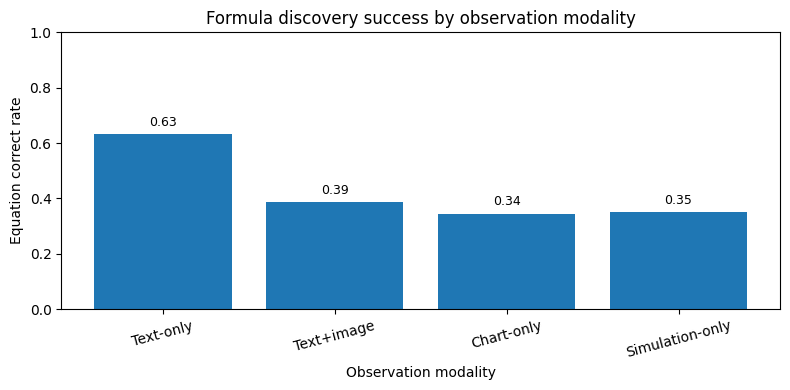

In [13]:
success_df = (
    main_df
    .groupby("modality_clean", as_index=False)
    .agg(
        success_rate=("equation_correct_int", "mean"),
        finish_wrong_rate=("finish_wrong_int", "mean"),
        n=("equation_correct_int", "size"),
    )
)

success_df["modality_clean"] = pd.Categorical(
    success_df["modality_clean"],
    categories=MODALITY_ORDER,
    ordered=True,
)

success_df = success_df.sort_values("modality_clean")

display(success_df)

fig, ax = plt.subplots(figsize=(8, 4))

ax.bar(success_df["modality_clean"], success_df["success_rate"])

ax.set_ylim(0, 1)
ax.set_ylabel("Equation correct rate")
ax.set_xlabel("Observation modality")
ax.set_title("Formula discovery success by observation modality")

for i, row in enumerate(success_df.itertuples()):
    ax.text(
        i,
        row.success_rate + 0.02,
        f"{row.success_rate:.2f}",
        ha="center",
        va="bottom",
        fontsize=9,
    )

plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

modality_clean,Text-only,Text+image,Chart-only,Simulation-only
formula,,,,
beers,0.619048,0.283333,0.116667,0.216667
distance,0.642857,0.466667,0.450000,0.350000
kinematics,0.661905,0.300000,0.300000,0.300000
mass,0.614286,0.383333,0.433333,0.400000
ohm,0.569378,0.316667,0.200000,0.233333
resistors,0.685714,0.566667,0.566667,0.600000


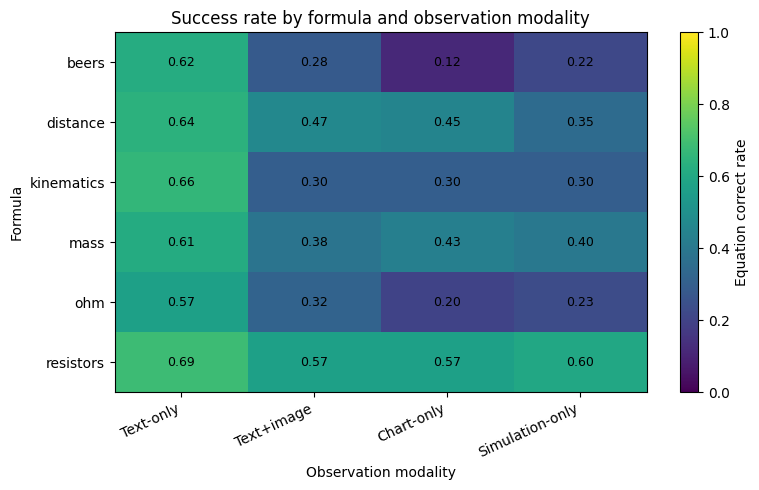

In [15]:
heat_df = (
    main_df
    .groupby(["formula", "modality_clean"], as_index=False)
    .agg(success_rate=("equation_correct_int", "mean"))
)

pivot = heat_df.pivot(
    index="formula",
    columns="modality_clean",
    values="success_rate",
)

pivot = pivot[[m for m in MODALITY_ORDER if m in pivot.columns]]

display(pivot)

fig, ax = plt.subplots(figsize=(8, 5))

im = ax.imshow(
    pivot.values,
    aspect="auto",
    vmin=0,
    vmax=1,
)

ax.set_xticks(range(len(pivot.columns)))
ax.set_xticklabels(pivot.columns, rotation=25, ha="right")

ax.set_yticks(range(len(pivot.index)))
ax.set_yticklabels(pivot.index)

for i in range(pivot.shape[0]):
    for j in range(pivot.shape[1]):
        val = pivot.iloc[i, j]
        if pd.notna(val):
            ax.text(
                j,
                i,
                f"{val:.2f}",
                ha="center",
                va="center",
                fontsize=9,
            )

ax.set_title("Success rate by formula and observation modality")
ax.set_xlabel("Observation modality")
ax.set_ylabel("Formula")

fig.colorbar(im, ax=ax, label="Equation correct rate")

plt.tight_layout()
plt.show()

modality_clean,Text-only,Text+image,Chart-only,Simulation-only
formula_setup,,,,
beers / concrete,0.800000,0.80,0.30,0.60
beers / abbrev,0.571429,0.05,0.05,0.05
beers / abstract,0.485714,0.00,0.00,0.00
distance / concrete,0.914286,0.75,0.60,0.60
distance / abbrev,0.542857,0.40,0.40,0.20
distance / abstract,0.471429,0.25,0.35,0.25
kinematics / concrete,0.928571,0.75,0.75,0.70
kinematics / abbrev,0.871429,0.15,0.15,0.20
kinematics / abstract,0.185714,0.00,0.00,0.00


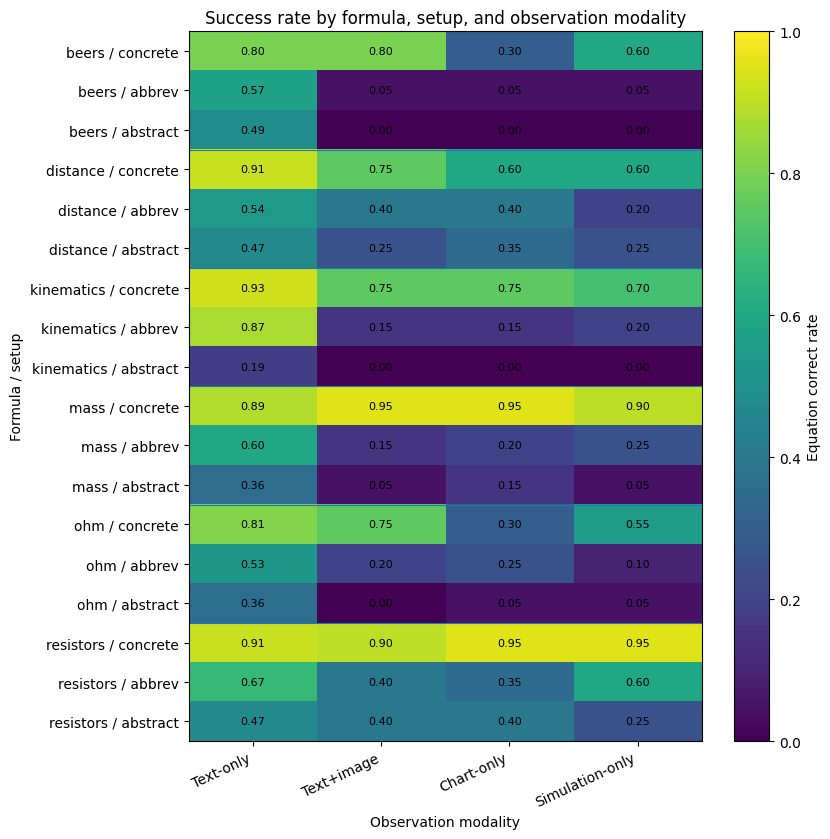

In [16]:
FORMULA_ORDER = [
    "beers",
    "distance",
    "kinematics",
    "mass",
    "ohm",
    "resistors",
]

SETUP_ORDER = [
    "concrete",
    "abbrev",
    "abstract",
]

MODALITY_ORDER = [
    "Text-only",
    "Text+image",
    "Chart-only",
    "Simulation-only",
]

detailed_df = main_df.copy()

detailed_df["formula"] = pd.Categorical(
    detailed_df["formula"],
    categories=FORMULA_ORDER,
    ordered=True,
)

detailed_df["setup"] = pd.Categorical(
    detailed_df["setup"],
    categories=SETUP_ORDER,
    ordered=True,
)

detailed_df["modality_clean"] = pd.Categorical(
    detailed_df["modality_clean"],
    categories=MODALITY_ORDER,
    ordered=True,
)

heat_df = (
    detailed_df
    .groupby(["formula", "setup", "modality_clean"], observed=True, as_index=False)
    .agg(success_rate=("equation_correct_int", "mean"))
)

heat_df["formula_setup"] = (
    heat_df["formula"].astype(str)
    + " / "
    + heat_df["setup"].astype(str)
)

row_order = [
    f"{formula} / {setup}"
    for formula in FORMULA_ORDER
    for setup in SETUP_ORDER
]

heat_df["formula_setup"] = pd.Categorical(
    heat_df["formula_setup"],
    categories=row_order,
    ordered=True,
)

pivot = heat_df.pivot(
    index="formula_setup",
    columns="modality_clean",
    values="success_rate",
)

pivot = pivot.reindex(row_order)
pivot = pivot[[m for m in MODALITY_ORDER if m in pivot.columns]]

display(pivot)

fig, ax = plt.subplots(figsize=(8.5, 8.5))

im = ax.imshow(
    pivot.values,
    aspect="auto",
    vmin=0,
    vmax=1,
)

ax.set_xticks(range(len(pivot.columns)))
ax.set_xticklabels(pivot.columns, rotation=25, ha="right")

ax.set_yticks(range(len(pivot.index)))
ax.set_yticklabels(pivot.index)

for i in range(pivot.shape[0]):
    for j in range(pivot.shape[1]):
        val = pivot.iloc[i, j]
        if pd.notna(val):
            ax.text(
                j,
                i,
                f"{val:.2f}",
                ha="center",
                va="center",
                fontsize=8,
            )

# 每三个 setup 后加一条横线，方便看公式分组
for y in [2.5, 5.5, 8.5, 11.5, 14.5]:
    ax.axhline(y=y, linewidth=0.8)

ax.set_title("Success rate by formula, setup, and observation modality")
ax.set_xlabel("Observation modality")
ax.set_ylabel("Formula / setup")

fig.colorbar(im, ax=ax, label="Equation correct rate")

plt.tight_layout()
plt.show()

In [17]:
FORMULA_ORDER = [
    "beers",
    "distance",
    "kinematics",
    "mass",
    "ohm",
    "resistors",
]

SETUP_ORDER = [
    "concrete",
    "abbrev",
    "abstract",
]

MODALITY_ORDER = [
    "Text-only",
    "Text+image",
    "Chart-only",
    "Simulation-only",
]


def plot_formula_setup_heatmap(formulas_to_plot, title):
    plot_df = main_df[
        main_df["formula"].isin(formulas_to_plot)
    ].copy()

    plot_df["formula"] = pd.Categorical(
        plot_df["formula"],
        categories=formulas_to_plot,
        ordered=True,
    )

    plot_df["setup"] = pd.Categorical(
        plot_df["setup"],
        categories=SETUP_ORDER,
        ordered=True,
    )

    plot_df["modality_clean"] = pd.Categorical(
        plot_df["modality_clean"],
        categories=MODALITY_ORDER,
        ordered=True,
    )

    heat_df = (
        plot_df
        .groupby(["formula", "setup", "modality_clean"], observed=True, as_index=False)
        .agg(success_rate=("equation_correct_int", "mean"))
    )

    heat_df["formula_setup"] = (
        heat_df["formula"].astype(str)
        + " / "
        + heat_df["setup"].astype(str)
    )

    row_order = [
        f"{formula} / {setup}"
        for formula in formulas_to_plot
        for setup in SETUP_ORDER
    ]

    heat_df["formula_setup"] = pd.Categorical(
        heat_df["formula_setup"],
        categories=row_order,
        ordered=True,
    )

    pivot = heat_df.pivot(
        index="formula_setup",
        columns="modality_clean",
        values="success_rate",
    )

    pivot = pivot.reindex(row_order)
    pivot = pivot[[m for m in MODALITY_ORDER if m in pivot.columns]]

    display(pivot)

    fig, ax = plt.subplots(figsize=(8.5, 4.8))

    im = ax.imshow(
        pivot.values,
        aspect="auto",
        vmin=0,
        vmax=1,
        cmap="YlGnBu",
    )

    ax.set_xticks(range(len(pivot.columns)))
    ax.set_xticklabels(
        pivot.columns,
        rotation=20,
        ha="right",
        fontsize=10,
    )

    ax.set_yticks(range(len(pivot.index)))
    ax.set_yticklabels(
        pivot.index,
        fontsize=10,
    )

    # 数字标注：深色格子用白字，浅色格子用黑字
    for i in range(pivot.shape[0]):
        for j in range(pivot.shape[1]):
            val = pivot.iloc[i, j]
            if pd.notna(val):
                text_color = "white" if val >= 0.55 else "black"
                ax.text(
                    j,
                    i,
                    f"{val:.2f}",
                    ha="center",
                    va="center",
                    fontsize=10,
                    color=text_color,
                    fontweight="bold",
                )

    # 加细网格线，让每个格子更清楚
    ax.set_xticks(np.arange(-0.5, len(pivot.columns), 1), minor=True)
    ax.set_yticks(np.arange(-0.5, len(pivot.index), 1), minor=True)
    ax.grid(which="minor", linewidth=0.6)
    ax.tick_params(which="minor", bottom=False, left=False)

    # 每三个 setup 后加粗一点的分隔线
    for y in [2.5, 5.5]:
        ax.axhline(y=y, linewidth=1.4, color="black")

    ax.set_title(title, fontsize=13)
    ax.set_xlabel("Observation modality", fontsize=11)
    ax.set_ylabel("Formula / setup", fontsize=11)

    cbar = fig.colorbar(im, ax=ax)
    cbar.set_label("Equation correct rate", fontsize=10)

    plt.tight_layout()
    plt.show()

modality_clean,Text-only,Text+image,Chart-only,Simulation-only
formula_setup,,,,
beers / concrete,0.800000,0.80,0.30,0.60
beers / abbrev,0.571429,0.05,0.05,0.05
beers / abstract,0.485714,0.00,0.00,0.00
distance / concrete,0.914286,0.75,0.60,0.60
distance / abbrev,0.542857,0.40,0.40,0.20
distance / abstract,0.471429,0.25,0.35,0.25
kinematics / concrete,0.928571,0.75,0.75,0.70
kinematics / abbrev,0.871429,0.15,0.15,0.20
kinematics / abstract,0.185714,0.00,0.00,0.00


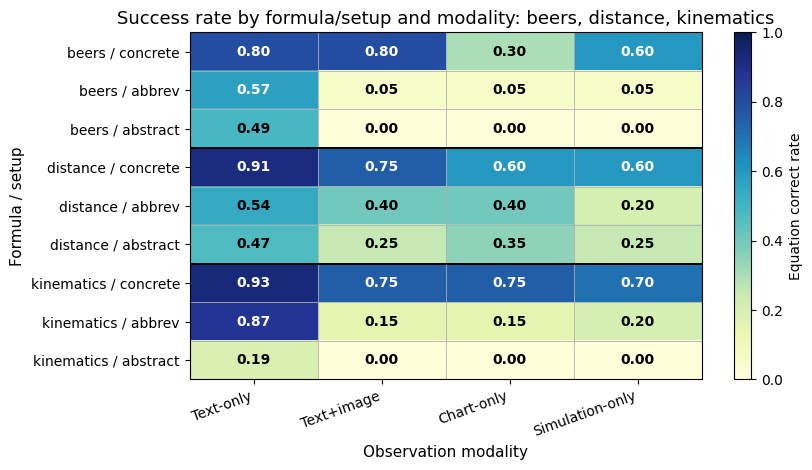

In [18]:
plot_formula_setup_heatmap(
    formulas_to_plot=["beers", "distance", "kinematics"],
    title="Success rate by formula/setup and modality: beers, distance, kinematics",
)

modality_clean,Text-only,Text+image,Chart-only,Simulation-only
formula_setup,,,,
mass / concrete,0.885714,0.95,0.95,0.90
mass / abbrev,0.600000,0.15,0.20,0.25
mass / abstract,0.357143,0.05,0.15,0.05
ohm / concrete,0.814286,0.75,0.30,0.55
ohm / abbrev,0.528571,0.20,0.25,0.10
ohm / abstract,0.362319,0.00,0.05,0.05
resistors / concrete,0.914286,0.90,0.95,0.95
resistors / abbrev,0.671429,0.40,0.35,0.60
resistors / abstract,0.471429,0.40,0.40,0.25


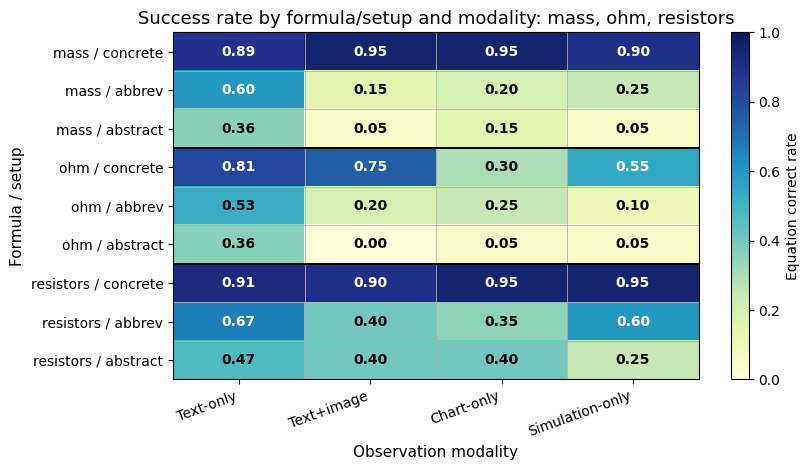

In [19]:
plot_formula_setup_heatmap(
    formulas_to_plot=["mass", "ohm", "resistors"],
    title="Success rate by formula/setup and modality: mass, ohm, resistors",
)

,finish_called_int,finish_wrong_int,forced_finish_int
modality_clean,,,
Text-only,1.000000,0.385226,0.048451
Text+image,0.994444,0.613889,0.000000
Chart-only,0.983333,0.655556,0.000000
Simulation-only,0.991667,0.650000,0.000000


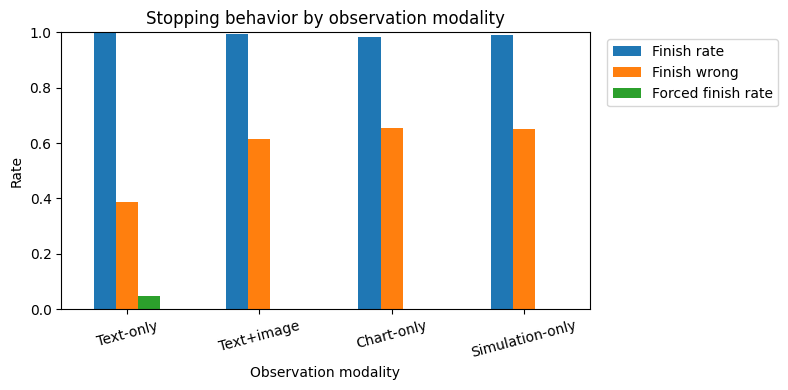

In [21]:
# Figure 4: Stopping behavior by modality

stop_metrics = [
    "finish_called_int",
    "finish_wrong_int",
    "forced_finish_int",
]

stop_df = (
    main_df
    .groupby("modality_clean")[stop_metrics]
    .mean()
    .reindex(MODALITY_ORDER)
)

display(stop_df)

ax = stop_df.plot(
    kind="bar",
    figsize=(8, 4),
)

ax.set_ylim(0, 1)
ax.set_ylabel("Rate")
ax.set_xlabel("Observation modality")
ax.set_title("Stopping behavior by observation modality")

plt.xticks(rotation=15)

ax.legend(
    labels=[
        "Finish rate",
        "Finish wrong ",
        "Forced finish rate",
    ],
    bbox_to_anchor=(1.02, 1),
    loc="upper left",
)

plt.tight_layout()
plt.show()

,modality_clean,mean_total_steps,median_total_steps,mean_steps_to_success
3,Text-only,5.911835,4.0,4.699749
2,Text+image,4.794444,4.0,4.028777
0,Chart-only,2.811111,2.0,2.137097
1,Simulation-only,2.638889,2.0,2.626984


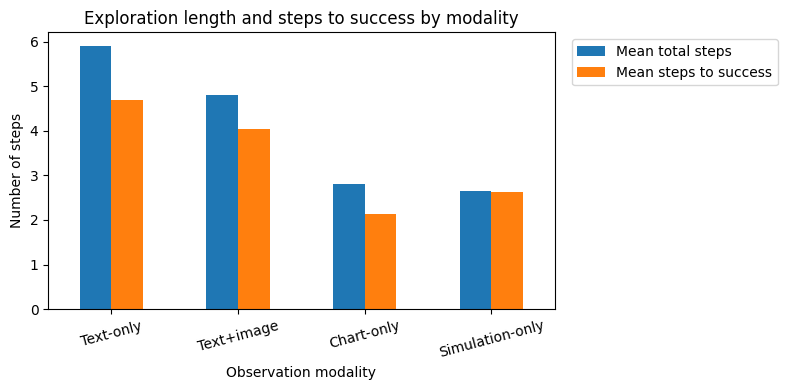

In [22]:
# Figure 5: Exploration length and steps to success by modality

step_df = (
    main_df
    .groupby("modality_clean", as_index=False)
    .agg(
        mean_total_steps=("total_steps", "mean"),
        median_total_steps=("total_steps", "median"),
        mean_steps_to_success=("steps_to_success", "mean"),
    )
)

step_df["modality_clean"] = pd.Categorical(
    step_df["modality_clean"],
    categories=MODALITY_ORDER,
    ordered=True,
)

step_df = step_df.sort_values("modality_clean")

display(step_df)

plot_step_df = step_df.set_index("modality_clean")[
    ["mean_total_steps", "mean_steps_to_success"]
]

ax = plot_step_df.plot(
    kind="bar",
    figsize=(8, 4),
)

ax.set_ylabel("Number of steps")
ax.set_xlabel("Observation modality")
ax.set_title("Exploration length and steps to success by modality")

plt.xticks(rotation=15)

ax.legend(
    labels=[
        "Mean total steps",
        "Mean steps to success",
    ],
    bbox_to_anchor=(1.02, 1),
    loc="upper left",
)

plt.tight_layout()
plt.show()

,state_coverage_ratio,controlled_experiments_ratio,redundancy_penalty
modality_clean,,,
Text-only,0.672486,0.291776,0.198998
Text+image,0.753898,0.188851,0.274480
Chart-only,0.759800,0.181151,0.119546
Simulation-only,0.765323,0.156880,0.098613


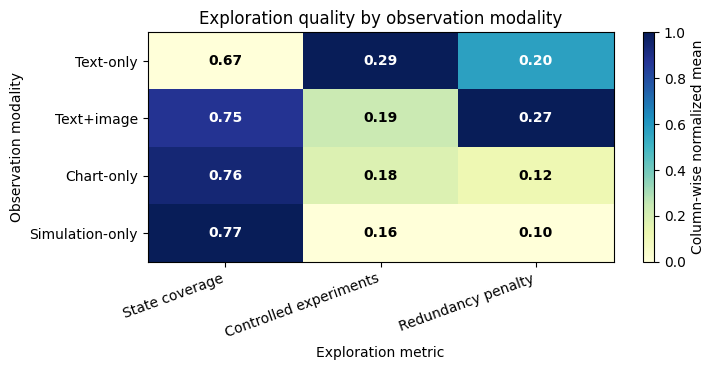

In [27]:
# Figure 6: Exploration quality overview heatmap

explore_metrics = [
    "state_coverage_ratio",
    "controlled_experiments_ratio",
    "redundancy_penalty",
]

quality_raw = (
    main_df
    .groupby("modality_clean")[explore_metrics]
    .mean()
    .reindex(MODALITY_ORDER)
)

display(quality_raw)

# column-wise normalization, only for color
quality_norm = quality_raw.copy()

for col in quality_norm.columns:
    col_min = quality_norm[col].min()
    col_max = quality_norm[col].max()
    if pd.isna(col_min) or pd.isna(col_max) or col_max == col_min:
        quality_norm[col] = 0.0
    else:
        quality_norm[col] = (quality_norm[col] - col_min) / (col_max - col_min)

fig, ax = plt.subplots(figsize=(7.5, 3.8))

im = ax.imshow(
    quality_norm.values,
    aspect="auto",
    vmin=0,
    vmax=1,
    cmap="YlGnBu",
)

ax.set_xticks(range(len(quality_norm.columns)))
ax.set_xticklabels(
    [
        "State coverage",
        "Controlled experiments",
        "Redundancy penalty",
    ],
    rotation=20,
    ha="right",
)

ax.set_yticks(range(len(quality_norm.index)))
ax.set_yticklabels(quality_norm.index)

for i in range(quality_raw.shape[0]):
    for j in range(quality_raw.shape[1]):
        raw_val = quality_raw.iloc[i, j]
        norm_val = quality_norm.iloc[i, j]
        text_color = "white" if norm_val >= 0.55 else "black"

        ax.text(
            j,
            i,
            f"{raw_val:.2f}",
            ha="center",
            va="center",
            fontsize=10,
            fontweight="bold",
            color=text_color,
        )

ax.set_title("Exploration quality by observation modality")
ax.set_xlabel("Exploration metric")
ax.set_ylabel("Observation modality")

cbar = fig.colorbar(im, ax=ax)
cbar.set_label("Column-wise normalized mean")

plt.tight_layout()
plt.show()

setup,concrete,abbrev,abstract
modality_clean,,,
Text-only,0.874634,0.0,0.0
Text+image,0.566553,0.0,0.0
Chart-only,0.543453,0.0,0.0
Simulation-only,0.470641,0.0,0.0


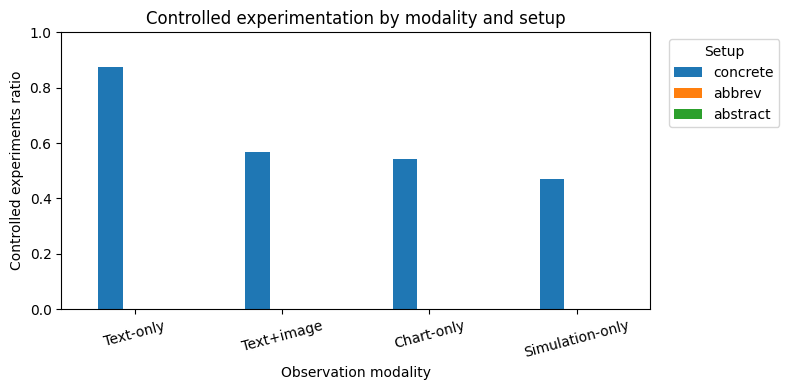

In [28]:
# Figure 7: Controlled experimentation by modality and setup

SETUP_ORDER = ["concrete", "abbrev", "abstract"]

control_df = (
    main_df
    .groupby(["modality_clean", "setup"], as_index=False)
    .agg(
        controlled_experiments_ratio=("controlled_experiments_ratio", "mean")
    )
)

control_df["modality_clean"] = pd.Categorical(
    control_df["modality_clean"],
    categories=MODALITY_ORDER,
    ordered=True,
)

control_df["setup"] = pd.Categorical(
    control_df["setup"],
    categories=SETUP_ORDER,
    ordered=True,
)

control_df = control_df.sort_values(["modality_clean", "setup"])

pivot_control = control_df.pivot(
    index="modality_clean",
    columns="setup",
    values="controlled_experiments_ratio",
).reindex(MODALITY_ORDER)

pivot_control = pivot_control[SETUP_ORDER]

display(pivot_control)

ax = pivot_control.plot(
    kind="bar",
    figsize=(8, 4),
)

ax.set_ylim(0, 1)
ax.set_ylabel("Controlled experiments ratio")
ax.set_xlabel("Observation modality")
ax.set_title("Controlled experimentation by modality and setup")

plt.xticks(rotation=15)

ax.legend(
    title="Setup",
    bbox_to_anchor=(1.02, 1),
    loc="upper left",
)

plt.tight_layout()
plt.show()

,state_coverage_ratio,redundancy_penalty
modality_clean,,
Text-only,0.672486,0.198998
Text+image,0.753898,0.274480
Chart-only,0.759800,0.119546
Simulation-only,0.765323,0.098613


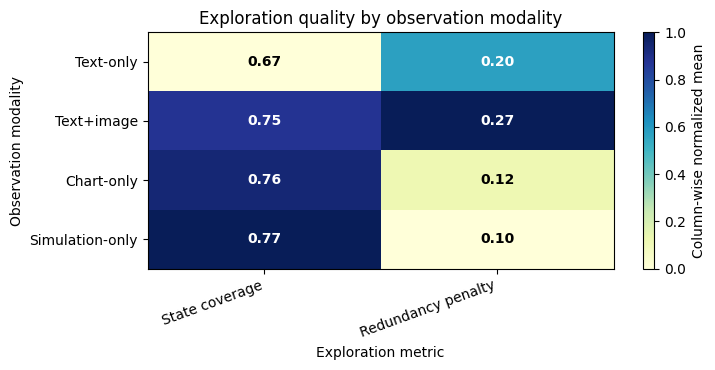

In [30]:
# Figure 6: Exploration quality overview heatmap
# Use metrics that are suitable for increase/decrease action mode.

explore_metrics = [
    "state_coverage_ratio",
    "redundancy_penalty",
]

quality_raw = (
    main_df
    .groupby("modality_clean")[explore_metrics]
    .mean()
    .reindex(MODALITY_ORDER)
)

display(quality_raw)

# Column-wise normalization only for color.
# The numbers shown in cells are still raw mean values.
quality_norm = quality_raw.copy()

for col in quality_norm.columns:
    col_min = quality_norm[col].min()
    col_max = quality_norm[col].max()
    if pd.isna(col_min) or pd.isna(col_max) or col_max == col_min:
        quality_norm[col] = 0.0
    else:
        quality_norm[col] = (quality_norm[col] - col_min) / (col_max - col_min)

fig, ax = plt.subplots(figsize=(7.5, 3.8))

im = ax.imshow(
    quality_norm.values,
    aspect="auto",
    vmin=0,
    vmax=1,
    cmap="YlGnBu",
)

ax.set_xticks(range(len(quality_norm.columns)))
ax.set_xticklabels(
    [
        "State coverage",
        "Redundancy penalty",
    ],
    rotation=20,
    ha="right",
)

ax.set_yticks(range(len(quality_norm.index)))
ax.set_yticklabels(quality_norm.index)

for i in range(quality_raw.shape[0]):
    for j in range(quality_raw.shape[1]):
        raw_val = quality_raw.iloc[i, j]
        norm_val = quality_norm.iloc[i, j]

        text_color = "white" if norm_val >= 0.55 else "black"

        ax.text(
            j,
            i,
            f"{raw_val:.2f}",
            ha="center",
            va="center",
            fontsize=10,
            fontweight="bold",
            color=text_color,
        )

ax.set_title("Exploration quality by observation modality")
ax.set_xlabel("Exploration metric")
ax.set_ylabel("Observation modality")

cbar = fig.colorbar(im, ax=ax)
cbar.set_label("Column-wise normalized mean")

plt.tight_layout()
plt.show()

In [31]:
display(
    main_df.groupby(["modality_clean", "setup"])["exploration_breadth_score"]
    .mean()
    .reset_index()
    .sort_values(["modality_clean", "setup"])
)

,modality_clean,setup,exploration_breadth_score
0,Chart-only,abbrev,0.764861
1,Chart-only,abstract,0.736525
2,Chart-only,concrete,0.778014
3,Simulation-only,abbrev,0.711525
4,Simulation-only,abstract,0.785064
5,Simulation-only,concrete,0.799380
6,Text+image,abbrev,0.721112
7,Text+image,abstract,0.751313
8,Text+image,concrete,0.789270
9,Text-only,abbrev,0.681285


setup,concrete,abbrev,abstract
modality_clean,,,
Text-only,0.656780,0.681285,0.679411
Text+image,0.789270,0.721112,0.751313
Chart-only,0.778014,0.764861,0.736525
Simulation-only,0.799380,0.711525,0.785064


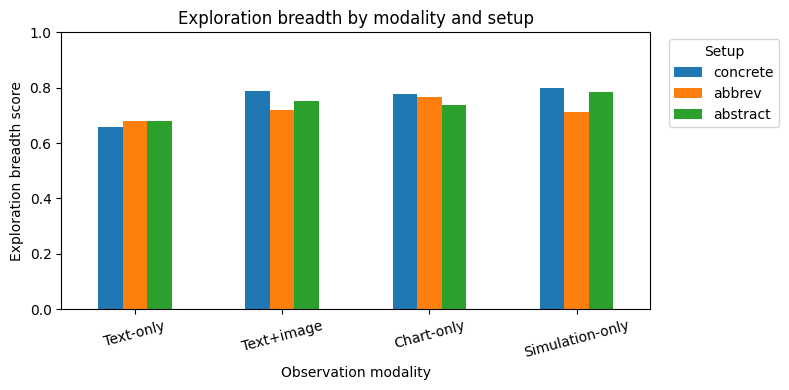

In [32]:
# Figure 7: Exploration breadth by modality and setup

SETUP_ORDER = ["concrete", "abbrev", "abstract"]

breadth_df = (
    main_df
    .groupby(["modality_clean", "setup"], as_index=False)
    .agg(
        exploration_breadth=("exploration_breadth_score", "mean")
    )
)

breadth_df["modality_clean"] = pd.Categorical(
    breadth_df["modality_clean"],
    categories=MODALITY_ORDER,
    ordered=True,
)

breadth_df["setup"] = pd.Categorical(
    breadth_df["setup"],
    categories=SETUP_ORDER,
    ordered=True,
)

breadth_df = breadth_df.sort_values(["modality_clean", "setup"])

pivot_breadth = breadth_df.pivot(
    index="modality_clean",
    columns="setup",
    values="exploration_breadth",
).reindex(MODALITY_ORDER)

pivot_breadth = pivot_breadth[SETUP_ORDER]

display(pivot_breadth)

ax = pivot_breadth.plot(
    kind="bar",
    figsize=(8, 4),
)

ax.set_ylim(0, 1)
ax.set_ylabel("Exploration breadth score")
ax.set_xlabel("Observation modality")
ax.set_title("Exploration breadth by modality and setup")

plt.xticks(rotation=15)

ax.legend(
    title="Setup",
    bbox_to_anchor=(1.02, 1),
    loc="upper left",
)

plt.tight_layout()
plt.show()

setup,concrete,abbrev,abstract
modality_clean,,,
Text-only,0.174260,0.212421,0.210342
Text+image,0.254929,0.329892,0.238618
Chart-only,0.084155,0.130056,0.144426
Simulation-only,0.085548,0.103755,0.106534


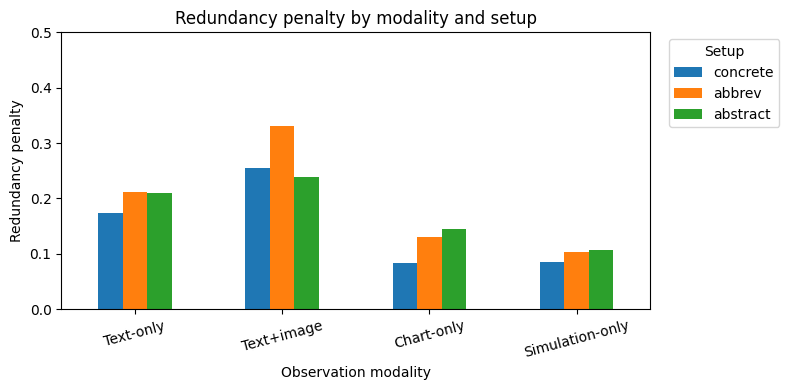

In [33]:
# Figure 8: Redundancy penalty by modality and setup

SETUP_ORDER = ["concrete", "abbrev", "abstract"]

redundancy_df = (
    main_df
    .groupby(["modality_clean", "setup"], as_index=False)
    .agg(
        redundancy_penalty=("redundancy_penalty", "mean")
    )
)

redundancy_df["modality_clean"] = pd.Categorical(
    redundancy_df["modality_clean"],
    categories=MODALITY_ORDER,
    ordered=True,
)

redundancy_df["setup"] = pd.Categorical(
    redundancy_df["setup"],
    categories=SETUP_ORDER,
    ordered=True,
)

redundancy_df = redundancy_df.sort_values(["modality_clean", "setup"])

pivot_redundancy = redundancy_df.pivot(
    index="modality_clean",
    columns="setup",
    values="redundancy_penalty",
).reindex(MODALITY_ORDER)

pivot_redundancy = pivot_redundancy[SETUP_ORDER]

display(pivot_redundancy)

ax = pivot_redundancy.plot(
    kind="bar",
    figsize=(8, 4),
)

ax.set_ylim(0, max(0.5, pivot_redundancy.max().max() + 0.05))
ax.set_ylabel("Redundancy penalty")
ax.set_xlabel("Observation modality")
ax.set_title("Redundancy penalty by modality and setup")

plt.xticks(rotation=15)

ax.legend(
    title="Setup",
    bbox_to_anchor=(1.02, 1),
    loc="upper left",
)

plt.tight_layout()
plt.show()

In [34]:
# Figure 9: Select a typical visual failure case

failure_candidates = main_df[
    (main_df["modality_clean"].isin(["Chart-only", "Simulation-only"])) &
    (main_df["termination_reason"].isin(["finish_wrong", "parse_error"]))
].copy()

failure_candidates = failure_candidates.sort_values(
    ["modality_clean", "formula", "setup", "total_steps"]
)

display(
    failure_candidates[
        [
            "modality_clean",
            "formula",
            "setup",
            "model",
            "total_steps",
            "termination_reason",
            "final_equation",
            "trajectory_path",
        ]
    ].head(20)
)

,modality_clean,formula,setup,model,total_steps,termination_reason,final_equation,trajectory_path
830,Chart-only,beers,abbrev,model_qwen25_vl_3b,1.0,finish_wrong,A = c * l + epsilon,\\wsl.localhost\Ubuntu\home\lly\projects\proje...
865,Chart-only,beers,abbrev,model_qwen25_vl_3b,1.0,finish_wrong,A = c * epsilon,\\wsl.localhost\Ubuntu\home\lly\projects\proje...
877,Chart-only,beers,abbrev,model_qwen25_vl_7b,1.0,finish_wrong,A = epsilon + c + l,\\wsl.localhost\Ubuntu\home\lly\projects\proje...
952,Chart-only,beers,abbrev,model_qwen25_vl_7b,1.0,finish_wrong,A = k * c,\\wsl.localhost\Ubuntu\home\lly\projects\proje...
990,Chart-only,beers,abbrev,model_qwen25_vl_3b,1.0,finish_wrong,A = epsilon + c,\\wsl.localhost\Ubuntu\home\lly\projects\proje...
1022,Chart-only,beers,abbrev,model_qwen25_vl_3b,1.0,finish_wrong,A = c + l,\\wsl.localhost\Ubuntu\home\lly\projects\proje...
1027,Chart-only,beers,abbrev,model_qwen25_vl_3b,1.0,finish_wrong,A = k * c + k * l,\\wsl.localhost\Ubuntu\home\lly\projects\proje...
1086,Chart-only,beers,abbrev,model_qwen25_vl_3b,2.0,parse_error,NaN,\\wsl.localhost\Ubuntu\home\lly\projects\proje...
831,Chart-only,beers,abbrev,model_qwen25_vl_7b,3.0,finish_wrong,A = 1 / (epsilon * c * l),\\wsl.localhost\Ubuntu\home\lly\projects\proje...
869,Chart-only,beers,abbrev,model_qwen25_vl_3b,3.0,finish_wrong,A = k * (c + l),\\wsl.localhost\Ubuntu\home\lly\projects\proje...


In [35]:
from pathlib import Path
import json
import pandas as pd

def load_json(path):
    with open(path, "r", encoding="utf-8") as f:
        return json.load(f)

case = failure_candidates.iloc[0]
traj = load_json(Path(case["trajectory_path"]))

case_rows = []

for step in traj:
    action = step.get("parsed_action")

    if isinstance(action, dict):
        action_str = f'{action.get("action_type")} {action.get("variable")}'
    else:
        action_str = None

    state_before = step.get("state_before")
    state_after = step.get("state_after")

    case_rows.append({
        "step_id": step.get("step_id"),
        "step_type": step.get("step_type"),
        "action": action_str,
        "state_before": state_before,
        "state_after": state_after,
        "final_equation": step.get("final_equation"),
        "reasoning": step.get("reasoning"),
    })

case_traj_df = pd.DataFrame(case_rows)

display(case[[
    "modality_clean",
    "formula",
    "setup",
    "model",
    "total_steps",
    "termination_reason",
    "final_equation",
]])

display(case_traj_df)

modality_clean                 Chart-only
formula                             beers
setup                              abbrev
model                  model_qwen25_vl_3b
total_steps                           1.0
termination_reason           finish_wrong
final_equation        A = c * l + epsilon
Name: 830, dtype: object

,step_id,step_type,action,state_before,state_after,final_equation,reasoning
0,0,finish,None,"{'molar_absorptivity': 2.0, 'concentration': 2...","{'molar_absorptivity': 2.0, 'concentration': 2...",A = c * l + epsilon,The bar chart shows that A has increased signi...


In [36]:
# Figure 10: Modality takeaway summary table

summary_df = (
    main_df
    .groupby("modality_clean", as_index=False)
    .agg(
        accuracy=("equation_correct_int", "mean"),
        finish_wrong_rate=("finish_wrong_int", "mean"),
        mean_total_steps=("total_steps", "mean"),
        mean_steps_to_success=("steps_to_success", "mean"),
        state_coverage=("state_coverage_ratio", "mean"),
        exploration_breadth=("exploration_breadth_score", "mean"),
        redundancy_penalty=("redundancy_penalty", "mean"),
    )
)

summary_df["modality_clean"] = pd.Categorical(
    summary_df["modality_clean"],
    categories=MODALITY_ORDER,
    ordered=True,
)

summary_df = summary_df.sort_values("modality_clean")

# Add qualitative failure mode based on previous results
failure_mode_map = {
    "Text-only": "Most accurate; longer exploration",
    "Text+image": "Higher redundancy; more wrong finishes",
    "Chart-only": "Short exploration; early wrong finish",
    "Simulation-only": "Short exploration; early wrong finish",
}

summary_df["main_failure_mode"] = summary_df["modality_clean"].astype(str).map(failure_mode_map)

display(summary_df)

,modality_clean,accuracy,finish_wrong_rate,mean_total_steps,mean_steps_to_success,state_coverage,exploration_breadth,redundancy_penalty,main_failure_mode
3,Text-only,0.632248,0.385226,5.911835,4.699749,0.672486,0.672486,0.198998,Most accurate; longer exploration
2,Text+image,0.386111,0.613889,4.794444,4.028777,0.753898,0.753898,0.274480,Higher redundancy; more wrong finishes
0,Chart-only,0.344444,0.655556,2.811111,2.137097,0.759800,0.759800,0.119546,Short exploration; early wrong finish
1,Simulation-only,0.350000,0.650000,2.638889,2.626984,0.765323,0.765323,0.098613,Short exploration; early wrong finish


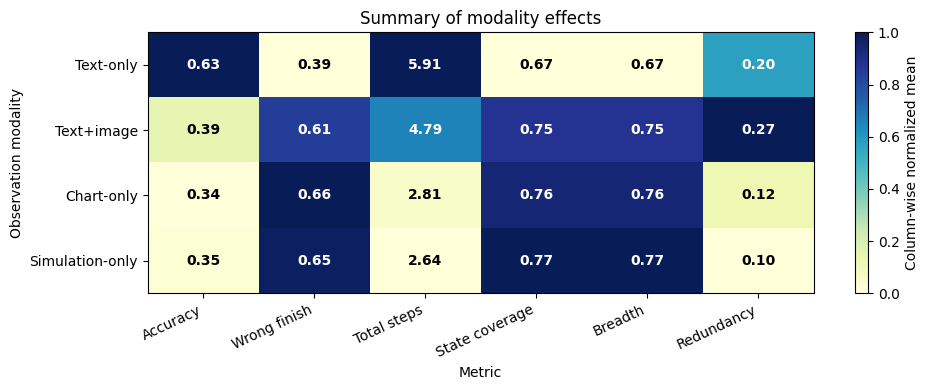

In [37]:
# Plot numeric summary as a compact heatmap

summary_metrics = [
    "accuracy",
    "finish_wrong_rate",
    "mean_total_steps",
    "state_coverage",
    "exploration_breadth",
    "redundancy_penalty",
]

summary_raw = summary_df.set_index("modality_clean")[summary_metrics]

# column-wise normalization for color only
summary_norm = summary_raw.copy()

for col in summary_norm.columns:
    col_min = summary_norm[col].min()
    col_max = summary_norm[col].max()
    if pd.isna(col_min) or pd.isna(col_max) or col_max == col_min:
        summary_norm[col] = 0.0
    else:
        summary_norm[col] = (summary_norm[col] - col_min) / (col_max - col_min)

fig, ax = plt.subplots(figsize=(10, 4))

im = ax.imshow(
    summary_norm.values,
    aspect="auto",
    vmin=0,
    vmax=1,
    cmap="YlGnBu",
)

ax.set_xticks(range(len(summary_raw.columns)))
ax.set_xticklabels(
    [
        "Accuracy",
        "Wrong finish",
        "Total steps",
        "State coverage",
        "Breadth",
        "Redundancy",
    ],
    rotation=25,
    ha="right",
)

ax.set_yticks(range(len(summary_raw.index)))
ax.set_yticklabels(summary_raw.index)

for i in range(summary_raw.shape[0]):
    for j in range(summary_raw.shape[1]):
        raw_val = summary_raw.iloc[i, j]
        norm_val = summary_norm.iloc[i, j]
        text_color = "white" if norm_val >= 0.55 else "black"

        ax.text(
            j,
            i,
            f"{raw_val:.2f}",
            ha="center",
            va="center",
            fontsize=10,
            fontweight="bold",
            color=text_color,
        )

ax.set_title("Summary of modality effects")
ax.set_xlabel("Metric")
ax.set_ylabel("Observation modality")

cbar = fig.colorbar(im, ax=ax)
cbar.set_label("Column-wise normalized mean")

plt.tight_layout()
plt.show()

,modality_clean,accuracy,mean_total_steps,wrong_finish_rate,efficiency
3,Text-only,0.632248,5.911835,0.385226,0.169152
2,Text+image,0.386111,4.794444,0.613889,0.208575
0,Chart-only,0.344444,2.811111,0.655556,0.355731
1,Simulation-only,0.350000,2.638889,0.650000,0.378947


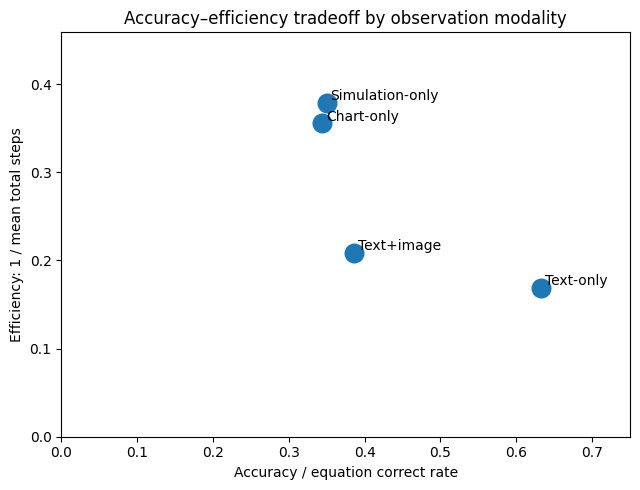

In [38]:
# Figure 11: Accuracy vs efficiency scatter by modality

scatter_df = (
    main_df
    .groupby("modality_clean", as_index=False)
    .agg(
        accuracy=("equation_correct_int", "mean"),
        mean_total_steps=("total_steps", "mean"),
        wrong_finish_rate=("finish_wrong_int", "mean"),
    )
)

scatter_df["efficiency"] = 1 / scatter_df["mean_total_steps"]

scatter_df["modality_clean"] = pd.Categorical(
    scatter_df["modality_clean"],
    categories=MODALITY_ORDER,
    ordered=True,
)

scatter_df = scatter_df.sort_values("modality_clean")

display(scatter_df)

fig, ax = plt.subplots(figsize=(6.5, 5))

ax.scatter(
    scatter_df["accuracy"],
    scatter_df["efficiency"],
    s=180,
)

for _, row in scatter_df.iterrows():
    ax.text(
        row["accuracy"] + 0.005,
        row["efficiency"] + 0.003,
        row["modality_clean"],
        fontsize=10,
    )

ax.set_xlabel("Accuracy / equation correct rate")
ax.set_ylabel("Efficiency: 1 / mean total steps")
ax.set_title("Accuracy–efficiency tradeoff by observation modality")

ax.set_xlim(0, max(0.75, scatter_df["accuracy"].max() + 0.08))
ax.set_ylim(0, scatter_df["efficiency"].max() + 0.08)

plt.tight_layout()
plt.show()

In [39]:
from pathlib import Path
import json
import itertools
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


def load_json_file(path):
    path = Path(path)
    if not path.exists():
        return None
    with open(path, "r", encoding="utf-8") as f:
        return json.load(f)


def action_to_token(step):
    """
    Convert one step into a compact trajectory token.
    """
    step_type = step.get("step_type")

    if step_type == "finish":
        return "finish"

    action = step.get("parsed_action")
    if isinstance(action, dict):
        action_type = action.get("action_type")
        variable = action.get("variable")
        return f"{action_type}:{variable}"

    return "invalid_action"


def extract_action_sequence(steps_path):
    """
    Extract action trajectory from steps.json.
    """
    steps = load_json_file(steps_path)
    if not isinstance(steps, list):
        return []

    seq = []
    for step in steps:
        token = action_to_token(step)
        seq.append(token)

    return seq


def edit_distance(seq1, seq2):
    """
    Standard Levenshtein distance over action-token sequences.
    """
    n, m = len(seq1), len(seq2)
    dp = np.zeros((n + 1, m + 1), dtype=int)

    for i in range(n + 1):
        dp[i, 0] = i
    for j in range(m + 1):
        dp[0, j] = j

    for i in range(1, n + 1):
        for j in range(1, m + 1):
            cost = 0 if seq1[i - 1] == seq2[j - 1] else 1
            dp[i, j] = min(
                dp[i - 1, j] + 1,
                dp[i, j - 1] + 1,
                dp[i - 1, j - 1] + cost,
            )

    return dp[n, m]


def normalized_edit_similarity(seq1, seq2):
    """
    Similarity = 1 - normalized edit distance.
    """
    max_len = max(len(seq1), len(seq2))

    if max_len == 0:
        return 1.0

    dist = edit_distance(seq1, seq2)
    return 1 - (dist / max_len)


def mean_pairwise_similarity(sequences, max_pairs=None, random_state=42):
    """
    Compute mean pairwise trajectory similarity.
    If max_pairs is set, sample pairs for speed.
    """
    sequences = [seq for seq in sequences if len(seq) > 0]

    if len(sequences) < 2:
        return np.nan

    all_pairs = list(itertools.combinations(range(len(sequences)), 2))

    if max_pairs is not None and len(all_pairs) > max_pairs:
        rng = np.random.default_rng(random_state)
        selected_idx = rng.choice(len(all_pairs), size=max_pairs, replace=False)
        all_pairs = [all_pairs[i] for i in selected_idx]

    sims = []
    for i, j in all_pairs:
        sims.append(normalized_edit_similarity(sequences[i], sequences[j]))

    return float(np.mean(sims))


traj_df = main_df.copy()

traj_df["action_sequence"] = traj_df["steps_path"].apply(extract_action_sequence)
traj_df["sequence_length"] = traj_df["action_sequence"].apply(len)

display(
    traj_df[[
        "modality_clean",
        "formula",
        "setup",
        "sequence_length",
        "action_sequence",
    ]].head()
)

,modality_clean,formula,setup,sequence_length,action_sequence
0,Simulation-only,distance,abbrev,1,[finish]
1,Simulation-only,kinematics,abbrev,2,"[increase:t, finish]"
2,Simulation-only,mass,abbrev,6,"[increase:V, increase:rho, increase:rho, incre..."
3,Simulation-only,resistors,abbrev,4,"[decrease:R1, decrease:R1, increase:R1, finish]"
4,Simulation-only,mass,abbrev,1,[finish]


,modality_clean,formula,setup,sequence_length,action_sequence
0,Simulation-only,distance,abbrev,1,[finish]
1,Simulation-only,kinematics,abbrev,2,"[increase:t, finish]"
2,Simulation-only,mass,abbrev,6,"[increase:V, increase:rho, increase:rho, incre..."
3,Simulation-only,resistors,abbrev,4,"[decrease:R1, decrease:R1, increase:R1, finish]"
4,Simulation-only,mass,abbrev,1,[finish]


,modality_clean,mean_pairwise_edit_similarity,trajectory_diversity,n
3,Text-only,0.218936,0.781064,1259
2,Text+image,0.266447,0.733553,360
0,Chart-only,0.404398,0.595602,360
1,Simulation-only,0.426348,0.573652,360


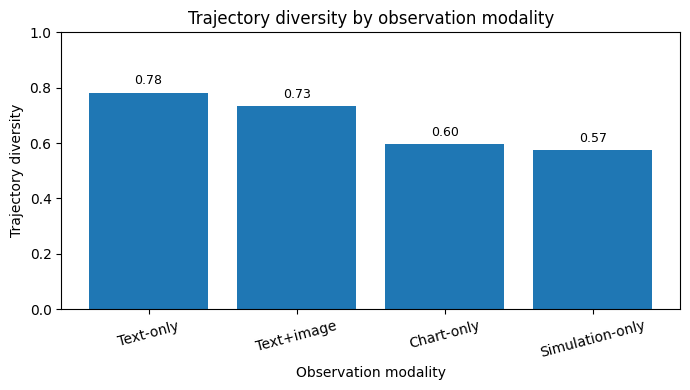

In [41]:
# Figure 12: Trajectory diversity by modality

from pathlib import Path
import json
import itertools
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


def load_json_file(path):
    path = Path(path)
    if not path.exists():
        return None
    with open(path, "r", encoding="utf-8") as f:
        return json.load(f)


def action_to_token(step):
    step_type = step.get("step_type")

    if step_type == "finish":
        return "finish"

    action = step.get("parsed_action")
    if isinstance(action, dict):
        action_type = action.get("action_type")
        variable = action.get("variable")
        return f"{action_type}:{variable}"

    return "invalid_action"


def extract_action_sequence(path):
    steps = load_json_file(path)

    if not isinstance(steps, list):
        return []

    return [action_to_token(step) for step in steps]


def edit_distance(seq1, seq2):
    n, m = len(seq1), len(seq2)
    dp = np.zeros((n + 1, m + 1), dtype=int)

    for i in range(n + 1):
        dp[i, 0] = i
    for j in range(m + 1):
        dp[0, j] = j

    for i in range(1, n + 1):
        for j in range(1, m + 1):
            cost = 0 if seq1[i - 1] == seq2[j - 1] else 1
            dp[i, j] = min(
                dp[i - 1, j] + 1,
                dp[i, j - 1] + 1,
                dp[i - 1, j - 1] + cost,
            )

    return dp[n, m]


def normalized_edit_similarity(seq1, seq2):
    max_len = max(len(seq1), len(seq2))

    if max_len == 0:
        return 1.0

    dist = edit_distance(seq1, seq2)
    return 1 - dist / max_len


def mean_pairwise_similarity(sequences, max_pairs=50000, random_state=42):
    sequences = [seq for seq in sequences if len(seq) > 0]

    if len(sequences) < 2:
        return np.nan

    all_pairs = list(itertools.combinations(range(len(sequences)), 2))

    if max_pairs is not None and len(all_pairs) > max_pairs:
        rng = np.random.default_rng(random_state)
        selected_idx = rng.choice(len(all_pairs), size=max_pairs, replace=False)
        all_pairs = [all_pairs[i] for i in selected_idx]

    sims = [
        normalized_edit_similarity(sequences[i], sequences[j])
        for i, j in all_pairs
    ]

    return float(np.mean(sims))


# 1. Extract action sequences
traj_df = main_df.copy()
traj_df["action_sequence"] = traj_df["steps_path"].apply(extract_action_sequence)
traj_df["sequence_length"] = traj_df["action_sequence"].apply(len)

display(
    traj_df[
        [
            "modality_clean",
            "formula",
            "setup",
            "sequence_length",
            "action_sequence",
        ]
    ].head()
)

# 2. Compute diversity by modality
diversity_rows = []

for modality, group in traj_df.groupby("modality_clean"):
    sequences = group["action_sequence"].tolist()

    mean_sim = mean_pairwise_similarity(
        sequences,
        max_pairs=50000,
        random_state=42,
    )

    diversity_rows.append({
        "modality_clean": modality,
        "mean_pairwise_edit_similarity": mean_sim,
        "trajectory_diversity": 1 - mean_sim,
        "n": len(group),
    })

diversity_df = pd.DataFrame(diversity_rows)

diversity_df["modality_clean"] = pd.Categorical(
    diversity_df["modality_clean"],
    categories=MODALITY_ORDER,
    ordered=True,
)

diversity_df = diversity_df.sort_values("modality_clean")

display(diversity_df)

# 3. Plot
fig, ax = plt.subplots(figsize=(7, 4))

ax.bar(
    diversity_df["modality_clean"],
    diversity_df["trajectory_diversity"],
)

ax.set_ylim(0, 1)
ax.set_ylabel("Trajectory diversity")
ax.set_xlabel("Observation modality")
ax.set_title("Trajectory diversity by observation modality")

for i, row in enumerate(diversity_df.itertuples()):
    ax.text(
        i,
        row.trajectory_diversity + 0.02,
        f"{row.trajectory_diversity:.2f}",
        ha="center",
        va="bottom",
        fontsize=9,
    )

plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

setup,concrete,abbrev,abstract
modality_clean,,,
Text-only,0.876190,0.630952,0.389021
Text+image,0.816667,0.225000,0.116667
Chart-only,0.641667,0.233333,0.158333
Simulation-only,0.716667,0.233333,0.100000


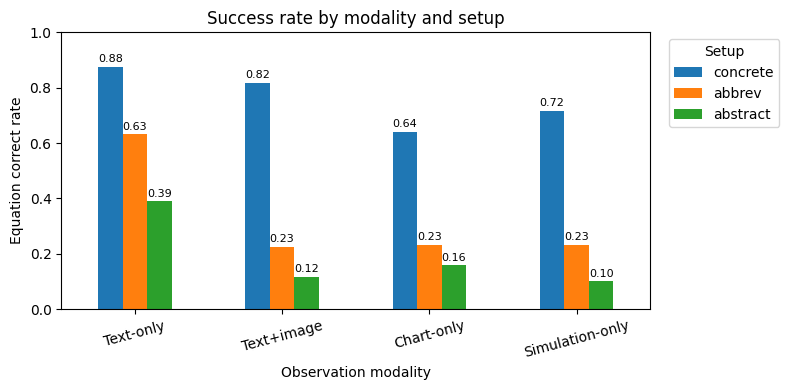

In [42]:
# Figure 13: Success rate by modality and setup

SETUP_ORDER = ["concrete", "abbrev", "abstract"]

setup_success_df = (
    main_df
    .groupby(["modality_clean", "setup"], as_index=False)
    .agg(
        success_rate=("equation_correct_int", "mean")
    )
)

setup_success_df["modality_clean"] = pd.Categorical(
    setup_success_df["modality_clean"],
    categories=MODALITY_ORDER,
    ordered=True,
)

setup_success_df["setup"] = pd.Categorical(
    setup_success_df["setup"],
    categories=SETUP_ORDER,
    ordered=True,
)

pivot_setup_success = setup_success_df.pivot(
    index="modality_clean",
    columns="setup",
    values="success_rate",
).reindex(MODALITY_ORDER)

pivot_setup_success = pivot_setup_success[SETUP_ORDER]

display(pivot_setup_success)

ax = pivot_setup_success.plot(
    kind="bar",
    figsize=(8, 4),
)

ax.set_ylim(0, 1)
ax.set_ylabel("Equation correct rate")
ax.set_xlabel("Observation modality")
ax.set_title("Success rate by modality and setup")

plt.xticks(rotation=15)

ax.legend(
    title="Setup",
    bbox_to_anchor=(1.02, 1),
    loc="upper left",
)

for container in ax.containers:
    ax.bar_label(container, fmt="%.2f", fontsize=8, padding=2)

plt.tight_layout()
plt.show()

In [43]:
from pathlib import Path
import json
import itertools
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display


def load_json_file(path):
    path = Path(path)
    if not path.exists():
        return None
    with open(path, "r", encoding="utf-8") as f:
        return json.load(f)


def step_to_token(step):
    """
    Convert one step into a compact token.
    Example:
    increase epsilon -> increase:epsilon
    finish -> FINISH
    """
    step_type = step.get("step_type")

    if step_type == "finish":
        return "FINISH"

    action = step.get("parsed_action")

    if isinstance(action, dict):
        action_type = action.get("action_type")
        variable = action.get("variable")

        if action_type and variable:
            return f"{action_type}:{variable}"

    return "INVALID"


def extract_steps(row):
    """
    Prefer steps.json; fallback to trajectory.json.
    """
    steps = load_json_file(row["steps_path"])

    if not isinstance(steps, list):
        steps = load_json_file(row["trajectory_path"])

    if not isinstance(steps, list):
        return []

    return steps


def extract_tokens(row):
    steps = extract_steps(row)
    return [step_to_token(step) for step in steps]


def is_action_token(token):
    return isinstance(token, str) and ":" in token and token != "INVALID"


def token_action_type(token):
    if is_action_token(token):
        return token.split(":", 1)[0]
    if token == "FINISH":
        return "finish"
    return "invalid"


def token_variable(token):
    if is_action_token(token):
        return token.split(":", 1)[1]
    return None


def extract_available_variables(row):
    """
    Get available action variables from trajectory.json observation metadata.
    This gives the denominator for variable coverage.
    """
    traj = load_json_file(row["trajectory_path"])

    if not isinstance(traj, list):
        return []

    for step in traj:
        for obs_key in ["observation_before", "observation_after"]:
            obs = step.get(obs_key)

            if not isinstance(obs, dict):
                continue

            actions = obs.get("available_actions")

            if isinstance(actions, list):
                variables = sorted({
                    a.get("variable")
                    for a in actions
                    if isinstance(a, dict) and a.get("variable")
                })

                if variables:
                    return variables

    return []


seq_rows = []

for _, row in main_df.iterrows():
    tokens = extract_tokens(row)
    action_tokens = [t for t in tokens if is_action_token(t)]
    variables = [token_variable(t) for t in action_tokens if token_variable(t) is not None]
    available_variables = extract_available_variables(row)

    first_action_token = "FINISH"
    for t in tokens:
        if is_action_token(t):
            first_action_token = t
            break
        if t == "FINISH":
            first_action_token = "FINISH"
            break

    seq_rows.append({
        "root": row["root"],
        "modality_clean": row["modality_clean"],
        "formula": row["formula"],
        "setup": row["setup"],
        "model": row["model"],
        "tokens": tokens,
        "action_tokens": action_tokens,
        "variables": variables,
        "available_variables": available_variables,
        "n_tokens": len(tokens),
        "n_actions": len(action_tokens),
        "first_action_token": first_action_token,
        "first_action_type": token_action_type(first_action_token),
        "first_action_variable": token_variable(first_action_token),
    })

seq_df = pd.DataFrame(seq_rows)

seq_df["modality_clean"] = pd.Categorical(
    seq_df["modality_clean"],
    categories=MODALITY_ORDER,
    ordered=True,
)

display(seq_df.head())
display(
    seq_df.groupby("modality_clean")[["n_tokens", "n_actions"]]
    .mean()
    .reindex(MODALITY_ORDER)
)

,root,modality_clean,formula,setup,model,tokens,action_tokens,variables,available_variables,n_tokens,n_actions,first_action_token,first_action_type,first_action_variable
0,image_only,Simulation-only,distance,abbrev,model_qwen25_vl_7b,[FINISH],[],[],"[d1, d2, d3]",1,0,FINISH,finish,NaN
1,image_only,Simulation-only,kinematics,abbrev,model_qwen25_vl_7b,"[increase:t, FINISH]",[increase:t],[t],"[t, v, x0]",2,1,increase:t,increase,t
2,image_only,Simulation-only,mass,abbrev,model_qwen25_vl_3b,"[increase:V, increase:rho, increase:rho, incre...","[increase:V, increase:rho, increase:rho, incre...","[V, rho, rho, rho, rho]","[V, rho]",6,5,increase:V,increase,V
3,image_only,Simulation-only,resistors,abbrev,model_qwen25_vl_3b,"[decrease:R1, decrease:R1, increase:R1, FINISH]","[decrease:R1, decrease:R1, increase:R1]","[R1, R1, R1]","[R1, R2]",4,3,decrease:R1,decrease,R1
4,image_only,Simulation-only,mass,abbrev,model_qwen25_vl_3b,[FINISH],[],[],"[V, rho]",1,0,FINISH,finish,NaN


,n_tokens,n_actions
modality_clean,,
Text-only,5.911835,4.960286
Text+image,4.794444,3.800000
Chart-only,2.811111,1.827778
Simulation-only,2.638889,1.647222


,modality_clean,first_k_pattern_diversity,unique_patterns,top_pattern_share,top_pattern,n
0,Text-only,0.882138,417,0.046863,increase:A → increase:B → FINISH,1259
1,Text+image,0.801850,140,0.277778,FINISH,360
2,Chart-only,0.711383,138,0.372222,FINISH,360
3,Simulation-only,0.703621,137,0.391667,FINISH,360


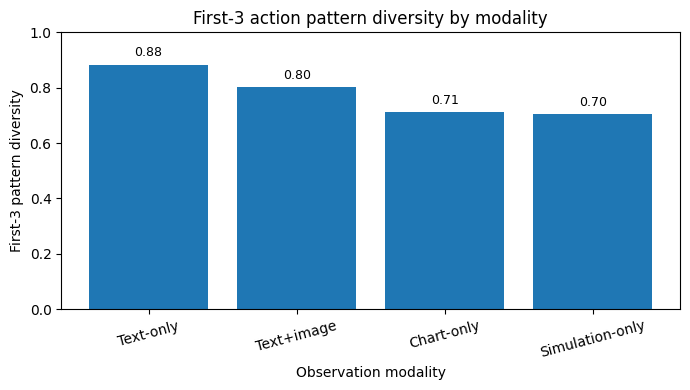

In [45]:
# Figure 12a: First-k action pattern diversity

K = 3

def first_k_pattern(tokens, k=3):
    if not isinstance(tokens, list):
        return ""

    selected = tokens[:k]

    if len(selected) == 0:
        return "EMPTY"

    return " → ".join(selected)


def normalized_entropy(series):
    counts = series.value_counts(dropna=False)
    probs = counts / counts.sum()

    if len(probs) <= 1:
        return 0.0

    entropy = -np.sum(probs * np.log(probs))
    return float(entropy / np.log(len(probs)))


pattern_df = seq_df.copy()
pattern_df["first_k_pattern"] = pattern_df["tokens"].apply(
    lambda x: first_k_pattern(x, K)
)

first_k_rows = []

for modality, group in pattern_df.groupby("modality_clean", observed=True):
    counts = group["first_k_pattern"].value_counts()

    first_k_rows.append({
        "modality_clean": modality,
        "first_k_pattern_diversity": normalized_entropy(group["first_k_pattern"]),
        "unique_patterns": counts.shape[0],
        "top_pattern_share": counts.iloc[0] / counts.sum(),
        "top_pattern": counts.index[0],
        "n": len(group),
    })

first_k_df = pd.DataFrame(first_k_rows)

first_k_df["modality_clean"] = pd.Categorical(
    first_k_df["modality_clean"],
    categories=MODALITY_ORDER,
    ordered=True,
)

first_k_df = first_k_df.sort_values("modality_clean")

display(first_k_df)

fig, ax = plt.subplots(figsize=(7, 4))

ax.bar(
    first_k_df["modality_clean"],
    first_k_df["first_k_pattern_diversity"],
)

ax.set_ylim(0, 1)
ax.set_ylabel(f"First-{K} pattern diversity")
ax.set_xlabel("Observation modality")
ax.set_title(f"First-{K} action pattern diversity by modality")

for i, row in enumerate(first_k_df.itertuples()):
    ax.text(
        i,
        row.first_k_pattern_diversity + 0.02,
        f"{row.first_k_pattern_diversity:.2f}",
        ha="center",
        va="bottom",
        fontsize=9,
    )

plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

,modality_clean,mean_bigram_jaccard_similarity,bigram_pattern_diversity,n
0,Text-only,0.022466,0.977534,1259
1,Text+image,0.090924,0.909076,360
2,Chart-only,0.157369,0.842631,360
3,Simulation-only,0.167892,0.832108,360


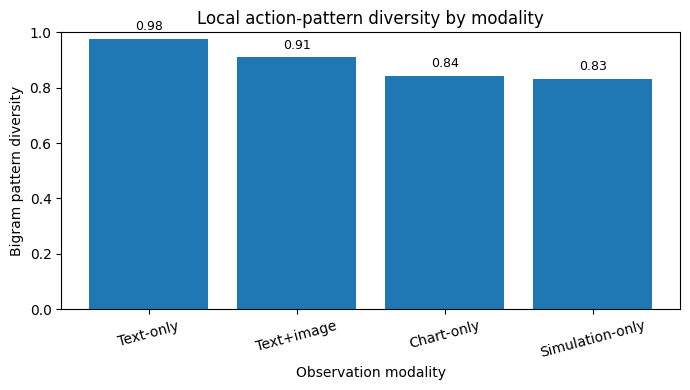

In [46]:
# Figure 12c: Action bigram pattern diversity by modality

NGRAM_N = 2


def make_ngrams(tokens, n=2):
    if not isinstance(tokens, list):
        return set()

    if len(tokens) < n:
        return set()

    return {
        tuple(tokens[i:i+n])
        for i in range(len(tokens) - n + 1)
    }


def jaccard_similarity(set1, set2):
    set1 = set(set1)
    set2 = set(set2)

    if len(set1) == 0 and len(set2) == 0:
        return 1.0

    if len(set1) == 0 or len(set2) == 0:
        return 0.0

    return len(set1 & set2) / len(set1 | set2)


def mean_pairwise_jaccard(sets, max_pairs=50000, random_state=42):
    sets = list(sets)

    if len(sets) < 2:
        return np.nan

    all_pairs = list(itertools.combinations(range(len(sets)), 2))

    if max_pairs is not None and len(all_pairs) > max_pairs:
        rng = np.random.default_rng(random_state)
        selected_idx = rng.choice(len(all_pairs), size=max_pairs, replace=False)
        all_pairs = [all_pairs[i] for i in selected_idx]

    sims = [
        jaccard_similarity(sets[i], sets[j])
        for i, j in all_pairs
    ]

    return float(np.mean(sims))


ngram_df = seq_df.copy()
ngram_df["action_bigrams"] = ngram_df["tokens"].apply(
    lambda x: make_ngrams(x, NGRAM_N)
)

ngram_rows = []

for modality, group in ngram_df.groupby("modality_clean", observed=True):
    mean_sim = mean_pairwise_jaccard(
        group["action_bigrams"],
        max_pairs=50000,
        random_state=42,
    )

    ngram_rows.append({
        "modality_clean": modality,
        "mean_bigram_jaccard_similarity": mean_sim,
        "bigram_pattern_diversity": 1 - mean_sim,
        "n": len(group),
    })

ngram_result_df = pd.DataFrame(ngram_rows)

ngram_result_df["modality_clean"] = pd.Categorical(
    ngram_result_df["modality_clean"],
    categories=MODALITY_ORDER,
    ordered=True,
)

ngram_result_df = ngram_result_df.sort_values("modality_clean")

display(ngram_result_df)

fig, ax = plt.subplots(figsize=(7, 4))

ax.bar(
    ngram_result_df["modality_clean"],
    ngram_result_df["bigram_pattern_diversity"],
)

ax.set_ylim(0, 1)
ax.set_ylabel("Bigram pattern diversity")
ax.set_xlabel("Observation modality")
ax.set_title("Local action-pattern diversity by modality")

for i, row in enumerate(ngram_result_df.itertuples()):
    ax.text(
        i,
        row.bigram_pattern_diversity + 0.02,
        f"{row.bigram_pattern_diversity:.2f}",
        ha="center",
        va="bottom",
        fontsize=9,
    )

plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

transition_type,switch variable,"same variable, different action",repeat same action,no transition
modality_clean,,,,
Text-only,0.471434,0.135353,0.359471,0.033742
Text+image,0.326861,0.135922,0.434466,0.102751
Chart-only,0.319938,0.098918,0.251932,0.329212
Simulation-only,0.306667,0.086667,0.231667,0.375000


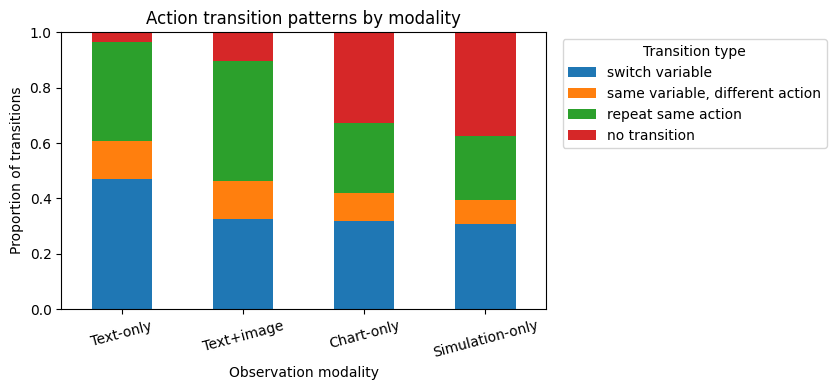

In [47]:
# Figure 12e: Transition pattern distribution by modality

def classify_transitions(action_tokens):
    if not isinstance(action_tokens, list) or len(action_tokens) < 2:
        return ["no transition"]

    transition_types = []

    for t1, t2 in zip(action_tokens[:-1], action_tokens[1:]):
        var1 = token_variable(t1)
        var2 = token_variable(t2)

        if t1 == t2:
            transition_types.append("repeat same action")
        elif var1 == var2:
            transition_types.append("same variable, different action")
        else:
            transition_types.append("switch variable")

    return transition_types


transition_rows = []

for _, row in seq_df.iterrows():
    transition_types = classify_transitions(row["action_tokens"])

    for transition_type in transition_types:
        transition_rows.append({
            "modality_clean": row["modality_clean"],
            "formula": row["formula"],
            "setup": row["setup"],
            "transition_type": transition_type,
        })

transition_df = pd.DataFrame(transition_rows)

transition_df["modality_clean"] = pd.Categorical(
    transition_df["modality_clean"],
    categories=MODALITY_ORDER,
    ordered=True,
)

transition_counts = (
    transition_df
    .groupby(["modality_clean", "transition_type"], observed=True)
    .size()
    .reset_index(name="count")
)

transition_counts["rate"] = (
    transition_counts
    .groupby("modality_clean")["count"]
    .transform(lambda x: x / x.sum())
)

pivot_transition = transition_counts.pivot(
    index="modality_clean",
    columns="transition_type",
    values="rate",
).fillna(0)

pivot_transition = pivot_transition.reindex(MODALITY_ORDER)

preferred_transition_order = [
    "switch variable",
    "same variable, different action",
    "repeat same action",
    "no transition",
]

pivot_transition = pivot_transition[
    [c for c in preferred_transition_order if c in pivot_transition.columns]
]

display(pivot_transition)

ax = pivot_transition.plot(
    kind="bar",
    stacked=True,
    figsize=(8.5, 4),
)

ax.set_ylim(0, 1)
ax.set_ylabel("Proportion of transitions")
ax.set_xlabel("Observation modality")
ax.set_title("Action transition patterns by modality")

plt.xticks(rotation=15)

ax.legend(
    title="Transition type",
    bbox_to_anchor=(1.02, 1),
    loc="upper left",
)

plt.tight_layout()
plt.show()

first_action_type,add,decrease,decrease R,decrease volume,finish,increase
modality_clean,,,,,,
Text-only,0.000000,0.073074,0.000794,0.000794,0.042891,0.882446
Text+image,0.000000,0.052778,0.000000,0.000000,0.280556,0.666667
Chart-only,0.002778,0.052778,0.000000,0.000000,0.377778,0.566667
Simulation-only,0.000000,0.083333,0.000000,0.000000,0.394444,0.522222


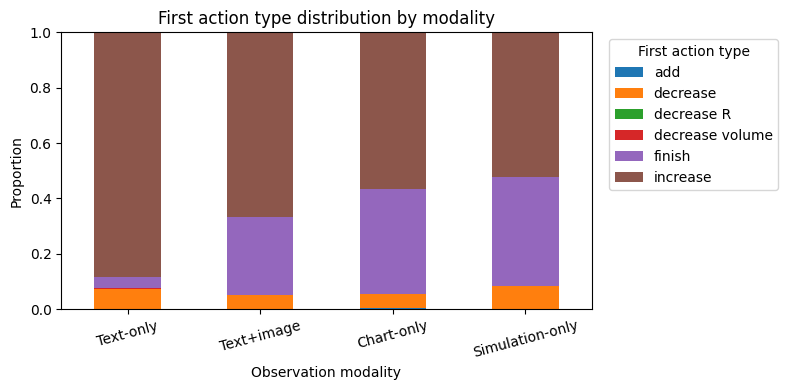

In [48]:
# Figure 12b: First action type distribution by modality

first_action_df = (
    seq_df
    .groupby(["modality_clean", "first_action_type"], observed=True)
    .size()
    .reset_index(name="count")
)

first_action_df["rate"] = (
    first_action_df
    .groupby("modality_clean")["count"]
    .transform(lambda x: x / x.sum())
)

pivot_first_action = first_action_df.pivot(
    index="modality_clean",
    columns="first_action_type",
    values="rate",
).fillna(0)

pivot_first_action = pivot_first_action.reindex(MODALITY_ORDER)

display(pivot_first_action)

ax = pivot_first_action.plot(
    kind="bar",
    stacked=True,
    figsize=(8, 4),
)

ax.set_ylim(0, 1)
ax.set_ylabel("Proportion")
ax.set_xlabel("Observation modality")
ax.set_title("First action type distribution by modality")

plt.xticks(rotation=15)

ax.legend(
    title="First action type",
    bbox_to_anchor=(1.02, 1),
    loc="upper left",
)

plt.tight_layout()
plt.show()

In [49]:
from pathlib import Path
import json
import pandas as pd
import numpy as np
from IPython.display import display


def load_json_file(path):
    path = Path(path)
    if not path.exists():
        return None
    with open(path, "r", encoding="utf-8") as f:
        return json.load(f)


def extract_step0_finish_info(row):
    """
    Extract information if the episode finishes at step 0.
    Prefer trajectory.json because it contains reasoning, raw output, observation, state.
    """
    traj = load_json_file(row["trajectory_path"])

    if not isinstance(traj, list) or len(traj) == 0:
        traj = load_json_file(row["steps_path"])

    if not isinstance(traj, list) or len(traj) == 0:
        return None

    step0 = traj[0]

    if step0.get("step_type") != "finish":
        return None

    obs_before = step0.get("observation_before", {}) or {}
    metadata = obs_before.get("metadata", {}) or {}

    return {
        "root": row.get("root"),
        "modality_clean": row.get("modality_clean"),
        "formula": row.get("formula"),
        "setup": row.get("setup"),
        "model": row.get("model"),
        "termination_reason": row.get("termination_reason"),
        "equation_correct": row.get("equation_correct"),
        "final_equation_summary": row.get("final_equation"),
        "total_steps": row.get("total_steps"),
        "step0_reasoning": step0.get("reasoning"),
        "step0_final_equation": step0.get("final_equation"),
        "raw_model_output": step0.get("raw_model_output"),
        "visible_state": obs_before.get("visible_state"),
        "target_variable": metadata.get("target_variable"),
        "target_variable_internal": metadata.get("target_variable_internal"),
        "image_path": obs_before.get("image_path"),
        "trajectory_path": row.get("trajectory_path"),
    }


one_step_rows = []

for _, row in main_df.iterrows():
    info = extract_step0_finish_info(row)
    if info is not None:
        one_step_rows.append(info)

one_step_finish_df = pd.DataFrame(one_step_rows)

print("Number of step-0 finish episodes:", len(one_step_finish_df))

display(
    one_step_finish_df[
        [
            "modality_clean",
            "formula",
            "setup",
            "model",
            "termination_reason",
            "equation_correct",
            "step0_final_equation",
            "step0_reasoning",
        ]
    ].head(20)
)

Number of step-0 finish episodes: 429


,modality_clean,formula,setup,model,termination_reason,equation_correct,step0_final_equation,step0_reasoning
0,Simulation-only,distance,abbrev,model_qwen25_vl_7b,finish_success,True,d = d1 + d2 + d3,The target variable (orange) seems to be direc...
1,Simulation-only,mass,abbrev,model_qwen25_vl_3b,finish_wrong,False,m = e^(rho * V),The orange bar represents the target variable ...
2,Simulation-only,distance,concrete,model_qwen25_vl_7b,finish_success,True,total_distance = distance_1 + distance_2 + dis...,"The blue bars represent distance_1, distance_2..."
3,Simulation-only,beers,concrete,model_qwen25_vl_7b,finish_wrong,False,A = ε * c * l,"The orange bar represents absorbance, and it a..."
4,Simulation-only,beers,abbrev,model_qwen25_vl_7b,finish_wrong,False,A = f(l),"The orange bar represents A, and there are two..."
5,Simulation-only,mass,concrete,model_qwen25_vl_3b,finish_success,True,mass = density * volume,"Observing the bar chart, the height of the ora..."
6,Simulation-only,resistors,abstract,model_qwen25_vl_7b,finish_success,True,Y = A + B,The orange bar represents the target variable ...
7,Simulation-only,resistors,concrete,model_qwen25_vl_7b,finish_success,True,total_resistance = resistance_1 + resistance_2,"The orange bar represents total_resistance, an..."
8,Simulation-only,ohm,concrete,model_qwen25_vl_3b,finish_success,True,voltage = current * resistance,"The bar chart shows a single large orange bar,..."
9,Simulation-only,resistors,abbrev,model_qwen25_vl_7b,finish_success,True,Rt = R1 + R2,"The orange bar represents Rt, which appears to..."


In [50]:
pd.set_option("display.max_colwidth", 300)

display(
    one_step_finish_df[
        [
            "modality_clean",
            "formula",
            "setup",
            "termination_reason",
            "equation_correct",
            "step0_final_equation",
            "step0_reasoning",
        ]
    ]
    .sort_values(["modality_clean", "formula", "setup"])
    .head(50)
)

,modality_clean,formula,setup,termination_reason,equation_correct,step0_final_equation,step0_reasoning
268,Chart-only,beers,abbrev,finish_wrong,False,A = c * l + epsilon,The bar chart shows that A has increased significantly compared to the previous states.
284,Chart-only,beers,abbrev,finish_wrong,False,A = c * epsilon,"The orange bar represents the target variable A, which is significantly larger than the blue bars representing epsilon and c. This suggests that A might be determined by a combination of epsilon and c. However, without further information, it's challenging to determine the exact relationship."
287,Chart-only,beers,abbrev,finish_wrong,False,A = epsilon + c + l,"The orange bar represents the target variable A, which is significantly larger than the blue bars. Given the lack of additional data, we assume the simplest relationship where A is directly proportional to the sum of the blue bars, epsilon + c + l."
315,Chart-only,beers,abbrev,finish_wrong,False,A = k * c,"The orange bar represents the target variable A, which is significantly larger than the blue bars representing c and l. There seems to be a strong positive correlation between A and c, while there's no clear pattern involving l. The blue bars could represent some form of scaling or distribution ..."
336,Chart-only,beers,abbrev,finish_wrong,False,A = epsilon + c,"The bar chart shows three bars with different heights. The tallest bar represents the target variable A, which is significantly higher than the other two blue bars representing the input variables epsilon and c. This suggests that A depends on both epsilon and c."
343,Chart-only,beers,abbrev,finish_wrong,False,A = c + l,"The orange bar represents the target variable A, while the two blue bars represent the input variables c and l. The height of A appears to be significantly higher than both c and l, suggesting that A is determined by both c and l."
346,Chart-only,beers,abbrev,finish_wrong,False,A = k * c + k * l,"The bar chart shows a clear relationship where the height of the orange bar (A) increases as the blue bars (c and l) increase, but the height of the blue bars themselves remains constant. This suggests that A is directly proportional to c and l."
260,Chart-only,beers,abstract,finish_wrong,False,Y = A + B + C,"The orange bar represents the target variable Y, while the blue bars represent input variables A, B, and C. From the current state, it appears that the value of Y is significantly higher than the values of A, B, and C. Since there are no additional images to explore, I cannot determine the exact..."
303,Chart-only,beers,abstract,finish_wrong,False,Y = A + B,"The orange bar represents variable Y, which is significantly higher than the blue bars representing A and B. This suggests a strong positive correlation between Y and the sum of A and B."
313,Chart-only,beers,abstract,finish_wrong,False,Y = A + B + C,"The orange bar represents the target variable Y, which appears to be the sum of the three blue bars. The blue bars seem to represent variables A, B, and C. Since the orange bar is significantly higher than the blue bars, it suggests that Y might be their sum."
